# Exploratory Data Analysis
GNN-BERT Music Context Understanding — CSE425

Explores the three datasets used across the four tasks:
- **MagnaTagATune** (Task 1) — tags + filenames
- **FMA-small** (Task 2) — genres + audio
- **MusicCaps** (Task 3/4) — captions + audio

Run after `01_data_acquisition.ipynb` and `02_preprocessing.ipynb`.

In [1]:
import os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW = os.path.join(PROJECT_ROOT, "data/raw")
PROC = os.path.join(PROJECT_ROOT, "data/processed")
print("Project root:", PROJECT_ROOT)

Project root: f:\BRACU\CSE425\Project\gnn-bert-music-context


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. MagnaTagATune (Task 1)

In [3]:
mtat = pd.read_csv(os.path.join(PROC, "mtat_top50_tags.csv"))
print("Shape:", mtat.shape)
mtat.head()

Shape: (25863, 52)


,clip_id,guitar,classical,slow,techno,strings,drums,electronic,rock,fast,...,beats,harp,cello,no voice,weird,country,metal,female voice,choral,mp3_path
0,2,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...
1,6,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...
2,10,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...
3,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...
4,12,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...


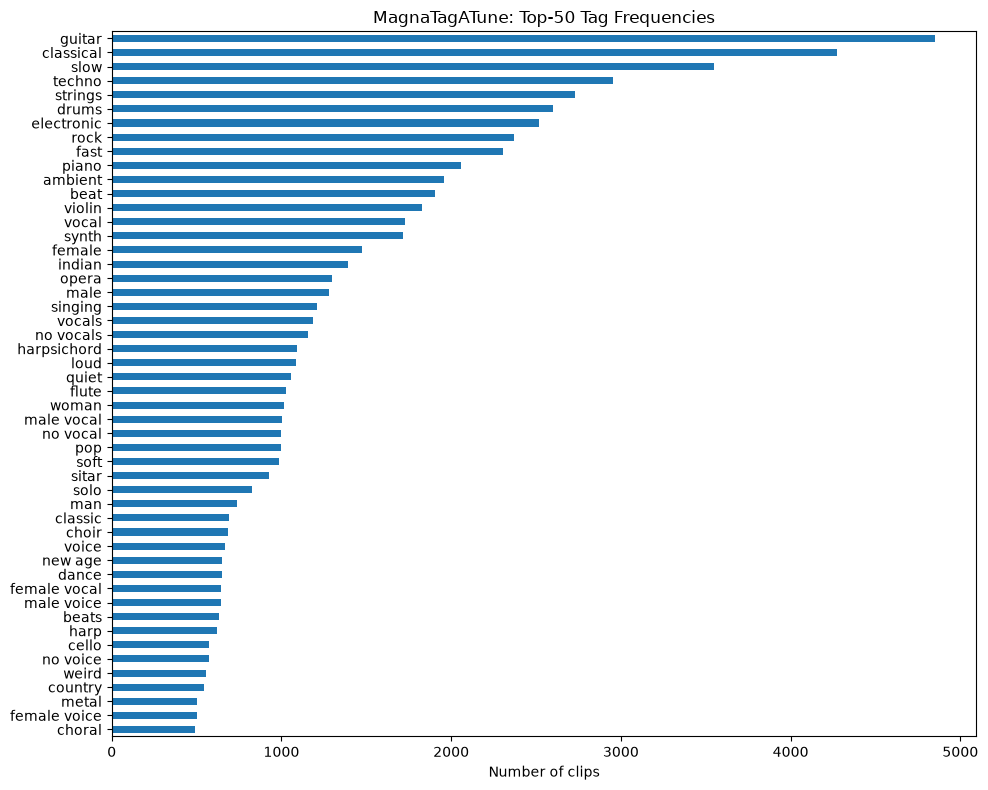

Most common tag: 'guitar' (4852 clips)
Least common (of top-50): 'choral' (490 clips)


In [4]:
tag_cols = [c for c in mtat.columns if c not in ["clip_id", "mp3_path"]]
tag_freq = mtat[tag_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
tag_freq.plot(kind="barh")
plt.title("MagnaTagATune: Top-50 Tag Frequencies")
plt.xlabel("Number of clips")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Most common tag: '{tag_freq.index[0]}' ({tag_freq.iloc[0]} clips)")
print(f"Least common (of top-50): '{tag_freq.index[-1]}' ({tag_freq.iloc[-1]} clips)")

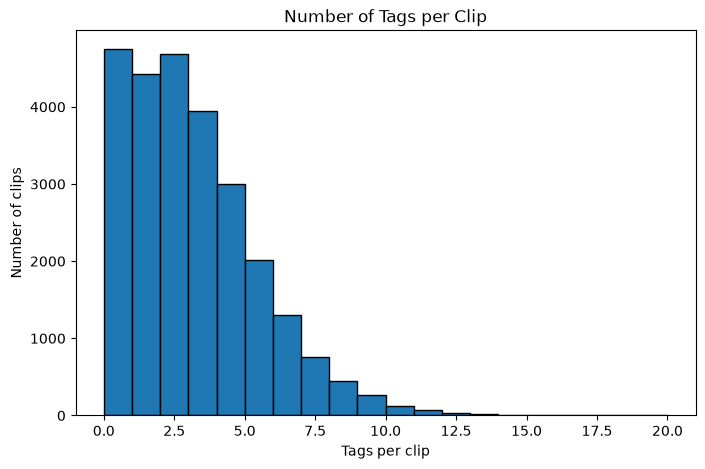

Mean tags per clip: 2.7
Clips with zero tags (of these top-50): 4752


In [5]:
# Tags per clip -- how multi-label is this really?
tags_per_clip = mtat[tag_cols].sum(axis=1)
plt.figure(figsize=(8, 5))
plt.hist(tags_per_clip, bins=range(0, int(tags_per_clip.max())+2), edgecolor="black")
plt.title("Number of Tags per Clip")
plt.xlabel("Tags per clip")
plt.ylabel("Number of clips")
plt.show()
print("Mean tags per clip:", tags_per_clip.mean().round(2))
print("Clips with zero tags (of these top-50):", (tags_per_clip == 0).sum())

## 2. FMA-small (Task 2)

Shape: (7994, 2)


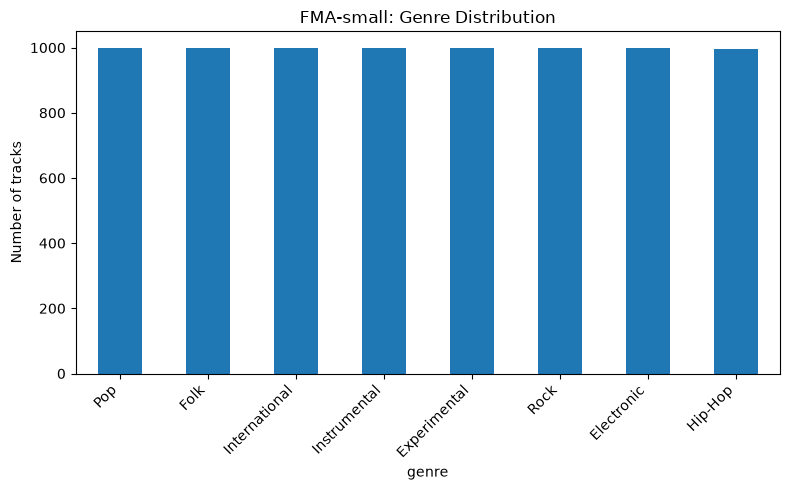

genre
Pop              1000
Folk             1000
International    1000
Instrumental     1000
Experimental      999
Rock              999
Electronic        999
Hip-Hop           997
Name: count, dtype: int64


In [6]:
fma_labels = pd.read_csv(os.path.join(PROC, "fma_small_labels_final.csv"))
print("Shape:", fma_labels.shape)

plt.figure(figsize=(8, 5))
fma_labels["genre"].value_counts().plot(kind="bar")
plt.title("FMA-small: Genre Distribution")
plt.ylabel("Number of tracks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(fma_labels["genre"].value_counts())

**Note:** FMA-small is deliberately balanced (~1000 tracks/genre) by design of the
original dataset -- this is why the bars above are nearly equal, unlike
MagnaTagATune's long-tail tag distribution.

## 3. MusicCaps (Task 3/4)

In [7]:
import ast
mc = pd.read_csv(os.path.join(RAW, "musiccaps/musiccaps-public.csv"))
mc_graph_manifest = pd.read_csv(os.path.join(PROC, "musiccaps_graph_manifest.csv"))
successful_ids = set(mc_graph_manifest[mc_graph_manifest["success"] == True]["ytid"])
mc_final = mc[mc["ytid"].isin(successful_ids)].reset_index(drop=True)
print("Successfully downloaded + processed clips:", len(mc_final), "/", len(mc), "total in MusicCaps")

Successfully downloaded + processed clips: 1159 / 5521 total in MusicCaps


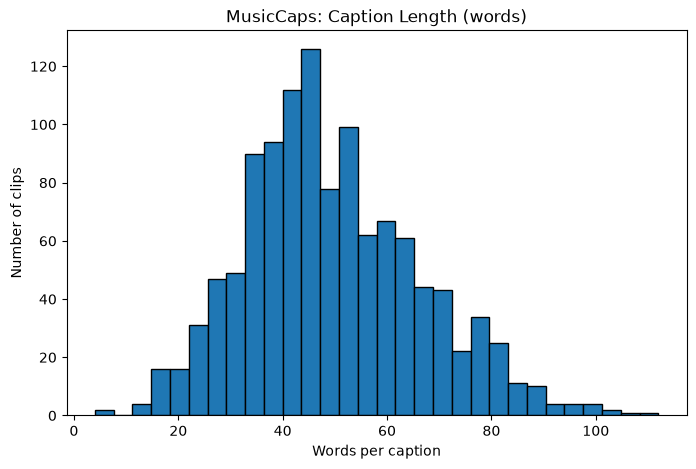

Mean caption length: 49.4 words
Example caption: The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.


In [8]:
# Caption length distribution
caption_lengths = mc_final["caption"].str.split().str.len()
plt.figure(figsize=(8, 5))
plt.hist(caption_lengths, bins=30, edgecolor="black")
plt.title("MusicCaps: Caption Length (words)")
plt.xlabel("Words per caption")
plt.ylabel("Number of clips")
plt.show()
print("Mean caption length:", caption_lengths.mean().round(1), "words")
print("Example caption:", mc_final.iloc[0]["caption"])

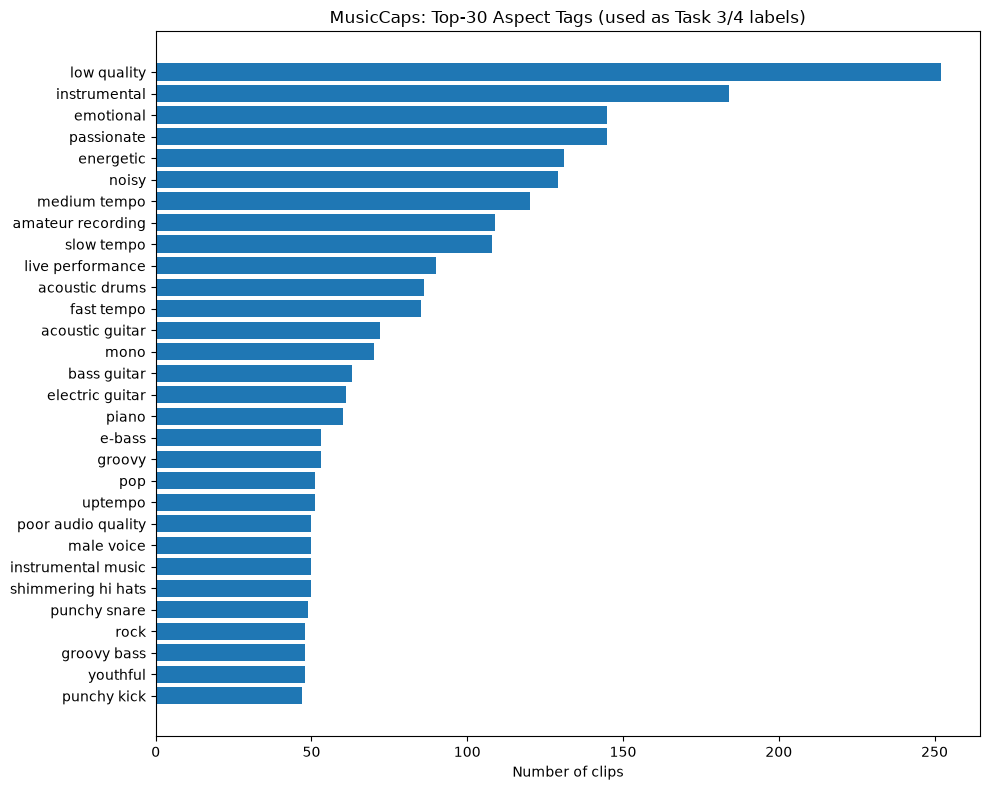

Total unique aspect phrases: 4219 (long-tail -- most appear only once or twice)


In [9]:
mc_final["aspect_parsed"] = mc_final["aspect_list"].apply(ast.literal_eval)
from collections import Counter
all_aspects = [a for aspects in mc_final["aspect_parsed"] for a in aspects]
aspect_counts = Counter(all_aspects)

top30 = aspect_counts.most_common(30)
labels_, counts_ = zip(*top30)

plt.figure(figsize=(10, 8))
plt.barh(labels_, counts_)
plt.title("MusicCaps: Top-30 Aspect Tags (used as Task 3/4 labels)")
plt.xlabel("Number of clips")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total unique aspect phrases: {len(aspect_counts)} (long-tail -- most appear only once or twice)")

## Summary

| Dataset | Clips | Labels | Text |
|---|---|---|---|
| MagnaTagATune | 25,863 rows (~5,405 unique tracks) | 50 tags (multi-label) | filename-derived pseudo-text |
| FMA-small | 7,994 (of 8,000) | 8 genres (single-label, balanced) | none (audio only) |
| MusicCaps | ~1,159 (of 5,521) | 30 aspect tags (multi-label, long-tail) | real natural-language captions |

See `results/metrics.json` and the main `README.md` for how each dataset
feeds into its respective task and the resulting model performance.